In [ ]:
from google.colab import drive   #Grape
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Run this first to install necessary packages
!pip install tensorflow==2.13.0
!pip install keras-cv
!pip install scikit-learn
!pip install matplotlib seaborn
!pip install Pillow

ERROR: Could not find a version that satisfies the requirement tensorflow==2.13.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0)
ERROR: No matching distribution found for tensorflow==2.13.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 44.0 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Model
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import os
import random

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Clear any previous memory   3
import gc
tf.keras.backend.clear_session()
gc.collect()

# Enable mixed precision training
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

print("="*70)
print("MEMORY OPTIMIZATION ENABLED")
print("="*70)
print(f'Compute dtype: {policy.compute_dtype}')
print(f'Variable dtype: {policy.variable_dtype}')
print("="*70 + "\n")

# OPTIMIZED Configuration for Colab Free Tier
DATASET_PATH = '/content/drive/MyDrive/cleaned_data'
IMG_SIZE = 128      # Reduced for memory
BATCH_SIZE = 8      # Reduced for memory
EPOCHS = 50
LEARNING_RATE = 0.001

# Verify path exists
import os
assert os.path.exists(DATASET_PATH), f"Path does not exist: {DATASET_PATH}"

print("="*70)
print("CONFIGURATION")
print("="*70)
print(f"Dataset Path: {DATASET_PATH}")
print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")
print("="*70 + "\n")

MEMORY OPTIMIZATION ENABLED
Compute dtype: float16
Variable dtype: float32

CONFIGURATION
Dataset Path: /content/drive/MyDrive/cleaned_data
Image Size: 128x128
Batch Size: 8
Epochs: 50
Learning Rate: 0.001



In [ ]:
# Data augmentation for training 4
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # 80% train, 20% validation
)

# Only rescaling for validation
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training data
print("Loading training data...")
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

# Load validation data
print("Loading validation data...")
validation_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

NUM_CLASSES = len(train_generator.class_indices)

print("\n" + "="*70)
print("DATASET LOADED")
print("="*70)
print(f"Number of classes: {NUM_CLASSES}")
print(f"Class names: {list(train_generator.class_indices.keys())}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Steps per epoch (train): {len(train_generator)}")
print(f"Steps per epoch (val): {len(validation_generator)}")
print("="*70 + "\n")

Loading training data...
Found 3251 images belonging to 4 classes.
Loading validation data...
Found 811 images belonging to 4 classes.

DATASET LOADED
Number of classes: 4
Class names: ['Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy']
Training samples: 3251
Validation samples: 811
Steps per epoch (train): 407
Steps per epoch (val): 102



In [ ]:
# Multi-Head Self-Attention Layer   5
class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, embed_dim, num_heads=8, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        if embed_dim % num_heads != 0:
            raise ValueError(
                f"embedding dimension = {embed_dim} should be divisible by number of heads = {num_heads}"
            )
        self.projection_dim = embed_dim // num_heads
        self.query_dense = layers.Dense(embed_dim)
        self.key_dense = layers.Dense(embed_dim)
        self.value_dense = layers.Dense(embed_dim)
        self.combine_heads = layers.Dense(embed_dim)

    def attention(self, query, key, value):
        score = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], dtype=score.dtype)
        scaled_score = score / tf.math.sqrt(dim_key)
        weights = tf.nn.softmax(scaled_score, axis=-1)
        output = tf.matmul(weights, value)
        return output, weights

    def separate_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        query = self.query_dense(inputs)
        key = self.key_dense(inputs)
        value = self.value_dense(inputs)
        query = self.separate_heads(query, batch_size)
        key = self.separate_heads(key, batch_size)
        value = self.separate_heads(value, batch_size)
        attention, weights = self.attention(query, key, value)
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim))
        output = self.combine_heads(concat_attention)
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            'embed_dim': self.embed_dim,
            'num_heads': self.num_heads
        })
        return config

# =========================================================
# MobileViTv2 Block (REPLACEMENT FOR MobileViTBlock)
# =========================================================
class MobileViTv2Block(layers.Layer):
    def __init__(self, projection_dim, num_heads=4, **kwargs):
        super().__init__(**kwargs)
        self.projection_dim = projection_dim
        self.num_heads = num_heads

    def build(self, input_shape):
        # Local representation
        self.conv1 = layers.Conv2D(
            self.projection_dim, 3, padding="same", activation="swish"
        )
        self.conv2 = layers.Conv2D(self.projection_dim, 1, padding="same")

        # Transformer (reuse existing MHSA)
        self.attention = MultiHeadSelfAttention(
            self.projection_dim, self.num_heads
        )
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)

        self.ffn = keras.Sequential([
            layers.Dense(self.projection_dim * 2, activation="swish"),
            layers.Dense(self.projection_dim)
        ])

        # Adaptive fusion gate (MobileViTv2-style)
        self.fusion_gate = layers.Dense(
            self.projection_dim, activation="sigmoid"
        )

        self.conv_out = layers.Conv2D(
            self.projection_dim, 3, padding="same", activation="swish"
        )

        super().build(input_shape)

    def call(self, inputs):
        # Local features
        local_feat = self.conv2(self.conv1(inputs))

        batch_size = tf.shape(local_feat)[0]
        height = tf.shape(local_feat)[1]
        width = tf.shape(local_feat)[2]

        # Tokenization
        tokens = tf.reshape(
            local_feat, [batch_size, height * width, self.projection_dim]
        )

        # Transformer block
        attn_out = self.attention(self.norm1(tokens))
        x = tokens + attn_out
        x = x + self.ffn(self.norm2(x))

        # Back to spatial
        global_feat = tf.reshape(
            x, [batch_size, height, width, self.projection_dim]
        )

        # MobileViTv2 adaptive fusion (NO CONCAT)
        gate = self.fusion_gate(global_feat)
        fused = gate * global_feat + (1.0 - gate) * local_feat

        return self.conv_out(fused)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[1], input_shape[2], self.projection_dim)

    def get_config(self):
        config = super().get_config()
        config.update({
            "projection_dim": self.projection_dim,
            "num_heads": self.num_heads
        })
        return config


In [ ]:
def create_hybrid_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):

    inputs = layers.Input(shape=input_shape)

    print("Building EfficientNetV2S branch...")
    efficientnet_base = EfficientNetV2S(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs,
        pooling=None
    )

    for layer in efficientnet_base.layers[:-10]:
        layer.trainable = False

    cnn_features = efficientnet_base.output

    # ===== Minimal MobileViTv2 Branch (LOGIC UPDATED ONLY) =====
    print("Building MobileViTv2 branch...")
    vit_input = layers.Conv2D(32, 3, strides=2, padding='same', activation='swish')(inputs)
    vit_input = layers.BatchNormalization()(vit_input)
    vit_input = layers.MaxPooling2D(2)(vit_input)

    # 🔁 ONLY CHANGE HERE
    vit_features = MobileViTv2Block(projection_dim=32, num_heads=2)(vit_input)

    vit_features = layers.GlobalAveragePooling2D()(vit_features)
    vit_features = layers.Reshape((1, 32))(vit_features)

    # ===== Feature Fusion (UNCHANGED) =====
    print("Building fusion layer...")
    cnn_pooled = layers.GlobalAveragePooling2D()(cnn_features)
    cnn_pooled = layers.Reshape((1, -1))(cnn_pooled)

    projection_dim = 128
    cnn_projected = layers.Dense(projection_dim)(cnn_pooled)
    vit_projected = layers.Dense(projection_dim)(vit_features)

    fused_features = layers.concatenate([cnn_projected, vit_projected], axis=-1)
    fused_features = layers.Flatten()(fused_features)

    # ===== Classification Head (UNCHANGED) =====
    print("Building classification head...")
    x = layers.Dense(128, activation='swish')(fused_features)
    x = layers.Dropout(0.3)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(64, activation='swish')(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = Model(inputs=inputs, outputs=outputs, name='Lightweight_Hybrid_Model')

    return model

# Create the model
print("\n" + "="*70)
print("CREATING HYBRID MODEL")
print("="*70)

model = create_hybrid_model()

# Display summary
print("\n" + "="*70)
print("MODEL ARCHITECTURE")
print("="*70)
model.summary()

# Calculate parameters
total_params = model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
non_trainable_params = total_params - trainable_params

print("\n" + "="*70)
print("PARAMETER STATISTICS")
print("="*70)
print(f"Total Parameters:         {total_params:>15,}")
print(f"Trainable Parameters:     {trainable_params:>15,} ({trainable_params/total_params*100:.1f}%)")
print(f"Non-Trainable Parameters: {non_trainable_params:>15,} ({non_trainable_params/total_params*100:.1f}%)")
print("="*70 + "\n")


CREATING HYBRID MODEL
Building EfficientNetV2S branch...
82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Building MobileViTv2 branch...
Building fusion layer...
Building classification head...

MODEL ARCHITECTURE


Model: "Lightweight_Hybrid_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │        648 │ rescaling[0][0]   │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │         96 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 64, 64,    │      5,184 │ stem_activation[… │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 64, 64,    │         96 │ block1a_project_… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 64, 64,    │          0 │ block1a_project_… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_add (Add)   │ (None, 64, 64,    │          0 │ block1a_project_… │
│                     │ 24)               │            │ stem_activation[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_co… │ (None, 64, 64,    │      5,184 │ block1a_add[0][0] │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_bn  │ (None, 64, 64,    │         96 │ block1b_project_… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_ac… │ (None, 64, 64,    │          0 │ block1b_project_… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_drop        │ (None, 64, 64,    │          0 │ block1b_project_… │
│ (Dropout)           │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_add (Add)   │ (None, 64, 64,    │          0 │ block1b_drop[0][… │
│                     │ 24)               │            │ block1a_add[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 32, 32,    │     20,736 │ block1b_add[0][0] │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 32, 32,    │        384 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 32, 32,    │          0 │ block2a_expand_b

 Total params: 20,542,500 (78.36 MB)

 Trainable params: 1,132,996 (4.32 MB)

 Non-trainable params: 19,409,504 (74.04 MB)


PARAMETER STATISTICS
Total Parameters:              20,542,500
Trainable Parameters:           1,132,996 (5.5%)
Non-Trainable Parameters:      19,409,504 (94.5%)



In [ ]:
# Compile with optimizer and loss  7
optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

print("="*70)
print("✓ MODEL COMPILED")
print("="*70)
print(f"Optimizer: Adam (lr={LEARNING_RATE})")
print(f"Loss: Categorical Crossentropy")
print(f"Metrics: Accuracy, Precision, Recall")
print("="*70 + "\n")

✓ MODEL COMPILED
Optimizer: Adam (lr=0.001)
Loss: Categorical Crossentropy
Metrics: Accuracy, Precision, Recall



In [ ]:
# Setup callbacks
checkpoint_path = 'best_hybrid_model.h5'

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Train the model
print("="*70)
print("STARTING TRAINING")
print("="*70)
print(f"Total Epochs: {EPOCHS}")
print(f"Training Samples: {train_generator.samples}")
print(f"Validation Samples: {validation_generator.samples}")
print(f"Steps per Epoch: {len(train_generator)}")
print(f"Validation Steps: {len(validation_generator)}")
print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print("="*70 + "\n")

try:
    history = model.fit(
        train_generator,
        validation_data=validation_generator,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    print("\n" + "="*70)
    print("TRAINING COMPLETED SUCCESSFULLY!")
    print("="*70)
    print(f"Total epochs trained: {len(history.history['accuracy'])}")
    print(f"Final training accuracy: {history.history['accuracy'][-1]*100:.2f}%")
    print(f"Final validation accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")
    print(f"Best model saved to: {checkpoint_path}")
    print("="*70 + "\n")

except Exception as e:
    print("\n" + "="*70)
    print("TRAINING ERROR")
    print("="*70)
    print(f"Error: {str(e)}")
    print("\nIf still OOM, reduce BATCH_SIZE to 4 or IMG_SIZE to 96")
    print("="*70 + "\n")
    raise

STARTING TRAINING
Total Epochs: 50
Training Samples: 3251
Validation Samples: 811
Steps per Epoch: 407
Validation Steps: 102
Image Size: 128x128
Batch Size: 8



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5891 - loss: 1.0059 - precision: 0.6547 - recall: 0.5045
Epoch 1: val_accuracy improved from -inf to 0.55487, saving model to best_hybrid_model.h5


407/407 ━━━━━━━━━━━━━━━━━━━━ 3212s 8s/step - accuracy: 0.5892 - loss: 1.0055 - precision: 0.6548 - recall: 0.5047 - val_accuracy: 0.5549 - val_loss: 1.0737 - val_precision: 0.6564 - val_recall: 0.4969 - learning_rate: 0.0010
Epoch 2/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.7506 - loss: 0.6564 - precision: 0.7854 - recall: 0.7022
Epoch 2: val_accuracy improved from 0.55487 to 0.78175, saving model to best_hybrid_model.h5


407/407 ━━━━━━━━━━━━━━━━━━━━ 49s 122ms/step - accuracy: 0.7506 - loss: 0.6563 - precision: 0.7854 - recall: 0.7023 - val_accuracy: 0.7818 - val_loss: 0.5440 - val_precision: 0.7899 - val_recall: 0.7694 - learning_rate: 0.0010
Epoch 3/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.8196 - loss: 0.4617 - precision: 0.8370 - recall: 0.8051
Epoch 3: val_accuracy improved from 0.78175 to 0.82861, saving model to best_hybrid_model.h5


...

407/407 ━━━━━━━━━━━━━━━━━━━━ 45s 107ms/step - accuracy: 0.9376 - loss: 0.2058 - precision: 0.9410 - recall: 0.9313 - val_accuracy: 0.9581 - val_loss: 0.1147 - val_precision: 0.9616 - val_recall: 0.9581 - learning_rate: 2.5000e-04
Epoch 36/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9335 - loss: 0.1995 - precision: 0.9397 - recall: 0.9290
Epoch 36: val_accuracy did not improve from 0.95808
407/407 ━━━━━━━━━━━━━━━━━━━━ 41s 100ms/step - accuracy: 0.9335 - loss: 0.1995 - precision: 0.9397 - recall: 0.9290 - val_accuracy: 0.9556 - val_loss: 0.1142 - val_precision: 0.9568 - val_recall: 0.9556 - learning_rate: 2.5000e-04
Epoch 37/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9419 - loss: 0.1856 - precision: 0.9453 - recall: 0.9368
Epoch 37: val_accuracy improved from 0.95808 to 0.96054, saving model to best_hybrid_model.h5


407/407 ━━━━━━━━━━━━━━━━━━━━ 41s 100ms/step - accuracy: 0.9419 - loss: 0.1856 - precision: 0.9453 - recall: 0.9368 - val_accuracy: 0.9605 - val_loss: 0.1174 - val_precision: 0.9627 - val_recall: 0.9556 - learning_rate: 2.5000e-04
Epoch 38/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9490 - loss: 0.1988 - precision: 0.9552 - recall: 0.9405
Epoch 38: val_accuracy did not improve from 0.96054
407/407 ━━━━━━━━━━━━━━━━━━━━ 40s 97ms/step - accuracy: 0.9490 - loss: 0.1988 - precision: 0.9552 - recall: 0.9405 - val_accuracy: 0.9507 - val_loss: 0.1249 - val_precision: 0.9530 - val_recall: 0.9494 - learning_rate: 2.5000e-04
Epoch 39/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9428 - loss: 0.1836 - precision: 0.9449 - recall: 0.9405
Epoch 39: val_accuracy improved from 0.96054 to 0.96547, saving model to best_hybrid_model.h5


407/407 ━━━━━━━━━━━━━━━━━━━━ 41s 101ms/step - accuracy: 0.9428 - loss: 0.1836 - precision: 0.9449 - recall: 0.9405 - val_accuracy: 0.9655 - val_loss: 0.1130 - val_precision: 0.9666 - val_recall: 0.9642 - learning_rate: 2.5000e-04
Epoch 40/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9450 - loss: 0.1664 - precision: 0.9512 - recall: 0.9396
Epoch 40: val_accuracy did not improve from 0.96547
407/407 ━━━━━━━━━━━━━━━━━━━━ 41s 100ms/step - accuracy: 0.9450 - loss: 0.1664 - precision: 0.9512 - recall: 0.9396 - val_accuracy: 0.9568 - val_loss: 0.1083 - val_precision: 0.9640 - val_recall: 0.9568 - learning_rate: 2.5000e-04
Epoch 41/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9210 - loss: 0.2259 - precision: 0.9259 - recall: 0.9144
Epoch 41: val_accuracy did not improve from 0.96547
407/407 ━━━━━━━━━━━━━━━━━━━━ 40s 99ms/step - accuracy: 0.9210 - loss: 0.2259 - precision: 0.9260 - recall: 0.9144 - val_accuracy: 0.9494 - val_loss: 0.1293 - val_precision: 0.9517 - val_

407/407 ━━━━━━━━━━━━━━━━━━━━ 42s 103ms/step - accuracy: 0.9356 - loss: 0.2174 - precision: 0.9397 - recall: 0.9301 - val_accuracy: 0.9679 - val_loss: 0.0905 - val_precision: 0.9679 - val_recall: 0.9679 - learning_rate: 2.5000e-04
Epoch 44/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9318 - loss: 0.1878 - precision: 0.9391 - recall: 0.9298
Epoch 44: val_accuracy did not improve from 0.96794
407/407 ━━━━━━━━━━━━━━━━━━━━ 40s 97ms/step - accuracy: 0.9318 - loss: 0.1878 - precision: 0.9391 - recall: 0.9298 - val_accuracy: 0.9482 - val_loss: 0.1335 - val_precision: 0.9504 - val_recall: 0.9445 - learning_rate: 2.5000e-04
Epoch 45/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9472 - loss: 0.1601 - precision: 0.9511 - recall: 0.9425
Epoch 45: val_accuracy did not improve from 0.96794
407/407 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - accuracy: 0.9472 - loss: 0.1602 - precision: 0.9511 - recall: 0.9425 - val_accuracy: 0.9519 - val_loss: 0.1375 - val_precision: 0.9542 - val_r

407/407 ━━━━━━━━━━━━━━━━━━━━ 42s 103ms/step - accuracy: 0.9468 - loss: 0.1689 - precision: 0.9494 - recall: 0.9418 - val_accuracy: 0.9692 - val_loss: 0.0957 - val_precision: 0.9703 - val_recall: 0.9667 - learning_rate: 2.5000e-04
Epoch 50/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9546 - loss: 0.1522 - precision: 0.9592 - recall: 0.9508
Epoch 50: val_accuracy did not improve from 0.96917
407/407 ━━━━━━━━━━━━━━━━━━━━ 42s 103ms/step - accuracy: 0.9546 - loss: 0.1522 - precision: 0.9592 - recall: 0.9508 - val_accuracy: 0.9568 - val_loss: 0.1101 - val_precision: 0.9580 - val_recall: 0.9568 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 48.

TRAINING COMPLETED SUCCESSFULLY!
Total epochs trained: 50
Final training accuracy: 95.23%
Final validation accuracy: 95.68%
Best model saved to: best_hybrid_model.h5



In [ ]:
best_epoch = np.argmax(history.history['val_accuracy']) + 1
print("Best Epoch (based on val_accuracy):", best_epoch)
print("Best Validation Accuracy:",
      max(history.history['val_accuracy']) * 100)


Best Epoch (based on val_accuracy): 49
Best Validation Accuracy: 96.91738486289978


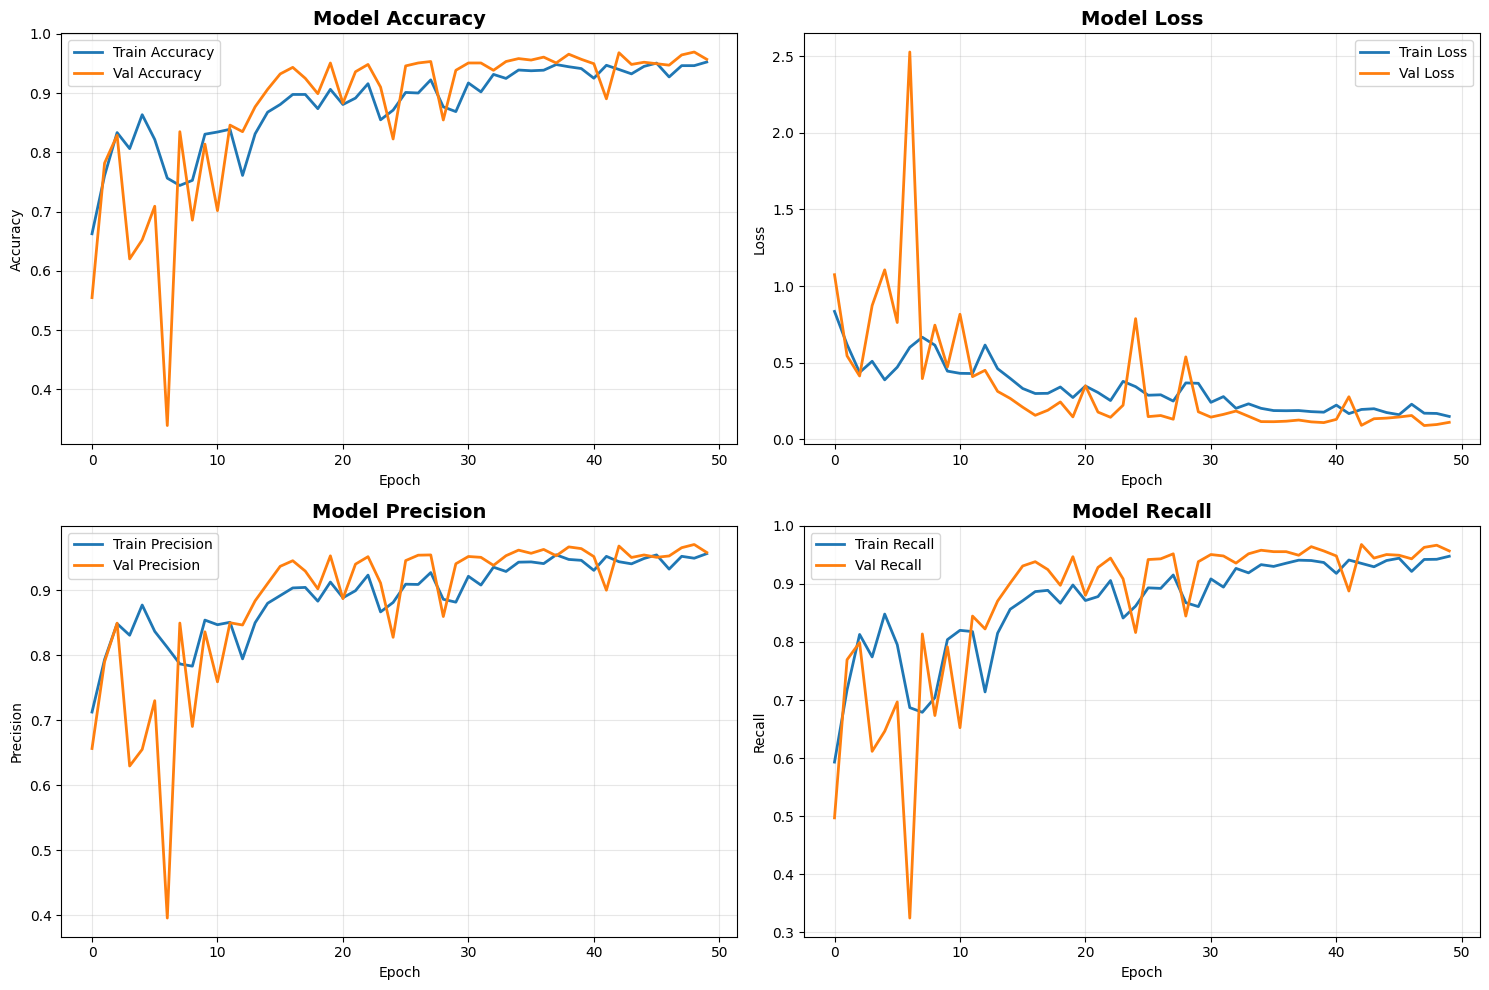

✓ Training history plot saved as 'training_history.png'


In [ ]:
def plot_training_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Loss
    axes[0, 1].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0, 1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Precision
    axes[1, 0].plot(history.history['precision'], label='Train Precision', linewidth=2)
    axes[1, 0].plot(history.history['val_precision'], label='Val Precision', linewidth=2)
    axes[1, 0].set_title('Model Precision', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Recall
    axes[1, 1].plot(history.history['recall'], label='Train Recall', linewidth=2)
    axes[1, 1].plot(history.history['val_recall'], label='Val Recall', linewidth=2)
    axes[1, 1].set_title('Model Recall', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✓ Training history plot saved as 'training_history.png'")

plot_training_history(history)

In [ ]:
# Evaluate on validation set
print("EVALUATING MODEL ON VALIDATION SET")

val_loss, val_accuracy, val_precision, val_recall = model.evaluate(
    validation_generator,
    verbose=0  # no progress bar
)

print(f"Validation Loss      : {val_loss:.4f}")
print(f"Validation Accuracy  : {val_accuracy * 100:.2f}%")
print(f"Validation Precision : {val_precision * 100:.2f}%")
print(f"Validation Recall    : {val_recall * 100:.2f}%")


EVALUATING MODEL ON VALIDATION SET
Validation Loss      : 0.1100
Validation Accuracy  : 96.18%
Validation Precision : 96.42%
Validation Recall    : 96.18%


In [ ]:
# Generate predictions
print("Generating predictions...")
validation_generator.reset()
y_pred_probs = model.predict(validation_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = validation_generator.classes

# Calculate detailed metrics
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("\n" + "="*70)
print("DETAILED METRICS")
print("="*70)
print(f"Weighted Precision: {precision*100:.2f}%")
print(f"Weighted Recall:    {recall*100:.2f}%")
print(f"Weighted F1-Score:  {f1*100:.2f}%")
print("="*70 + "\n")

Generating predictions...
102/102 ━━━━━━━━━━━━━━━━━━━━ 63s 293ms/step

DETAILED METRICS
Weighted Precision: 96.72%
Weighted Recall:    96.67%
Weighted F1-Score:  96.68%



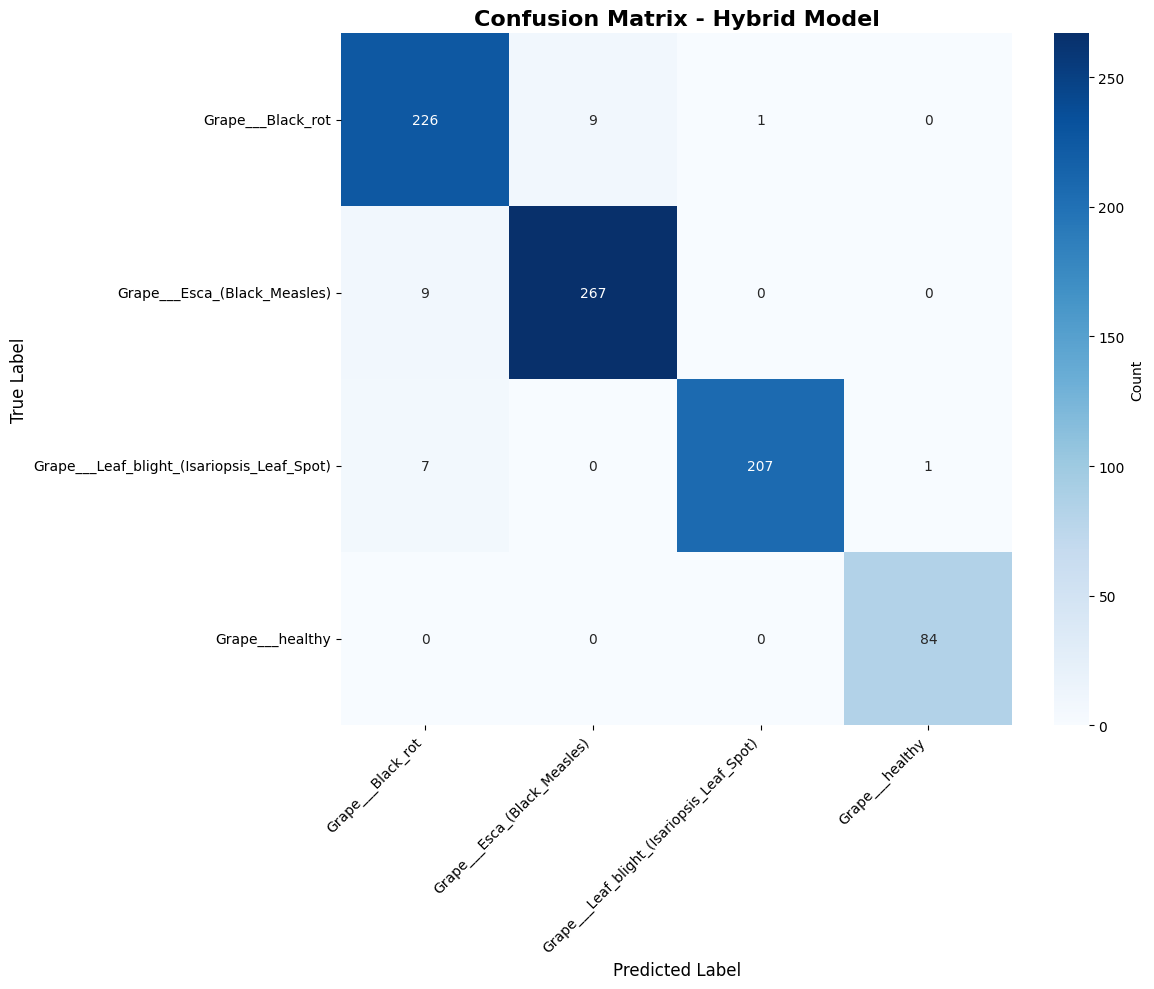

✓ Confusion matrix saved as 'confusion_matrix.png'


In [ ]:
# Compute and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_names = list(validation_generator.class_indices.keys())

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Hybrid Model', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix saved as 'confusion_matrix.png'")

In [ ]:
# Print detailed classification report
print("CLASSIFICATION REPORT")
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

CLASSIFICATION REPORT
                                            precision    recall  f1-score   support

                         Grape___Black_rot     0.9339    0.9576    0.9456       236
              Grape___Esca_(Black_Measles)     0.9674    0.9674    0.9674       276
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)     0.9952    0.9628    0.9787       215
                           Grape___healthy     0.9882    1.0000    0.9941        84

                                  accuracy                         0.9667       811
                                 macro avg     0.9712    0.9720    0.9715       811
                              weighted avg     0.9672    0.9667    0.9668       811



In [ ]:
# ===== STEP 14: Save the Model Permanently in Google Drive =====

import os

# Make sure this path exists (Drive already mounted earlier)
drive_folder_path = "/content/drive/MyDrive/Plant_Leaf_Project"
os.makedirs(drive_folder_path, exist_ok=True)

# Define full save paths inside Drive
keras_model_path = os.path.join(drive_folder_path, "hybrid_model_final.keras")
weights_path = os.path.join(drive_folder_path, "hybrid_model.weights.h5")

# Save model
model.save(keras_model_path)
print(f"✓ Model saved in Keras format: {keras_model_path}")

model.save_weights(weights_path)
print(f"✓ Model weights saved: {weights_path}")

print("\n" + "="*70)
print("MODEL SAVED SUCCESSFULLY IN GOOGLE DRIVE")
print("="*70)
print(f"  1. {keras_model_path} - Full model (recommended)")
print(f"  2. {weights_path} - Weights only")
print("="*70 + "\n")

# Verify file sizes
if os.path.exists(keras_model_path):
    keras_size = os.path.getsize(keras_model_path) / (1024 * 1024)
    print(f" Keras model size: {keras_size:.2f} MB")

if os.path.exists(weights_path):
    weights_size = os.path.getsize(weights_path) / (1024 * 1024)
    print(f" Weights size: {weights_size:.2f} MB")

print("\n✓ Model saved permanently in Google Drive!")


✓ Model saved in Keras format: /content/drive/MyDrive/Plant_Leaf_Project/hybrid_model_final.keras
✓ Model weights saved: /content/drive/MyDrive/Plant_Leaf_Project/hybrid_model.weights.h5

MODEL SAVED SUCCESSFULLY IN GOOGLE DRIVE
  1. /content/drive/MyDrive/Plant_Leaf_Project/hybrid_model_final.keras - Full model (recommended)
  2. /content/drive/MyDrive/Plant_Leaf_Project/hybrid_model.weights.h5 - Weights only

 Keras model size: 98.07 MB
 Weights size: 97.59 MB

✓ Model saved permanently in Google Drive!


TESTING RANDOM IMAGES FROM DATASET



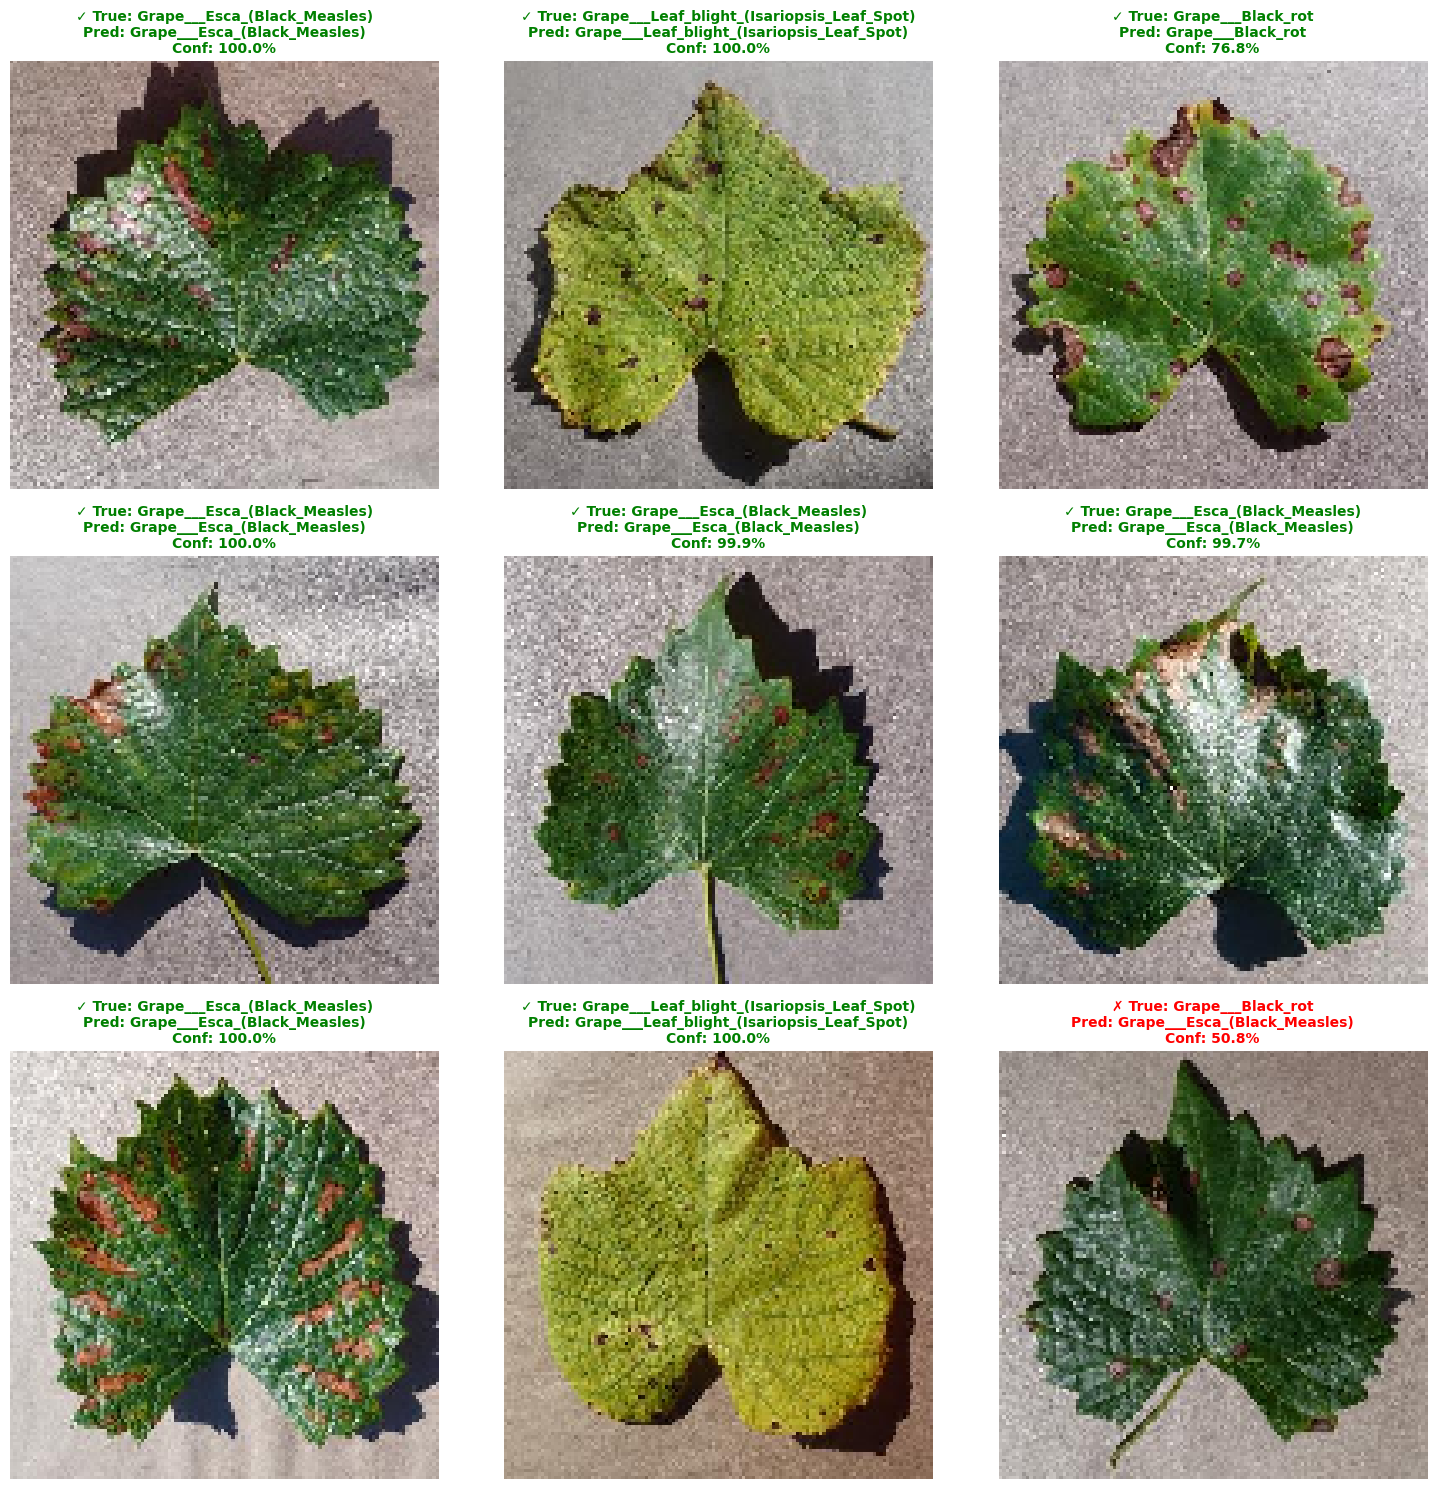


TEST RESULTS
Total images tested: 9
Correct predictions: 8
Wrong predictions: 1
Accuracy: 88.89%



88.88888888888889

In [ ]:
import random
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

def predict_disease(img_path, model, class_names):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    predicted_class = class_names[predicted_class_idx]
    confidence = predictions[0][predicted_class_idx] * 100

    top_3_idx = np.argsort(predictions[0])[-3:][::-1]

    return predicted_class, confidence, top_3_idx, predictions[0], img

def test_random_images_from_dataset(dataset_path, model, class_names, num_images=9):
    print("="*70)
    print("TESTING RANDOM IMAGES FROM DATASET")
    print("="*70 + "\n")

    all_image_paths = []
    true_labels = []

    for class_name in class_names:
        class_folder = os.path.join(dataset_path, class_name)
        if os.path.exists(class_folder):
            images = [f for f in os.listdir(class_folder)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            for img_name in images:
                all_image_paths.append(os.path.join(class_folder, img_name))
                true_labels.append(class_name)

    selected_indices = random.sample(range(len(all_image_paths)), min(num_images, len(all_image_paths)))

    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.ravel()

    correct_predictions = 0

    for idx, img_idx in enumerate(selected_indices):
        img_path = all_image_paths[img_idx]
        true_label = true_labels[img_idx]

        predicted_class, confidence, top_3_idx, predictions, img = predict_disease(
            img_path, model, class_names
        )

        if predicted_class == true_label:
            color = 'green'
            correct_predictions += 1
            status = '✓'
        else:
            color = 'red'
            status = '✗'

        axes[idx].imshow(img)
        axes[idx].axis('off')
        axes[idx].set_title(
            f'{status} True: {true_label}\nPred: {predicted_class}\nConf: {confidence:.1f}%',
            fontsize=10,
            fontweight='bold',
            color=color
        )

    plt.tight_layout()
    plt.savefig('test_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()

    accuracy = (correct_predictions / len(selected_indices)) * 100

    print(f"\n{'='*70}")
    print(f"TEST RESULTS")
    print(f"{'='*70}")
    print(f"Total images tested: {len(selected_indices)}")
    print(f"Correct predictions: {correct_predictions}")
    print(f"Wrong predictions: {len(selected_indices) - correct_predictions}")
    print(f"Accuracy: {accuracy:.2f}%")
    print(f"{'='*70}\n")

    return accuracy

class_names = list(train_generator.class_indices.keys())
test_random_images_from_dataset(DATASET_PATH, model, class_names, num_images=9)

In [ ]:
import os

folder_path = "/content/drive/MyDrive/Plant_Leaf_Project"
print(os.listdir(folder_path))

['hybrid_model_final.keras', 'hybrid_model.weights.h5']


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, embed_dim, num_heads=8, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.projection_dim = embed_dim // num_heads
        self.query_dense = layers.Dense(embed_dim)
        self.key_dense = layers.Dense(embed_dim)
        self.value_dense = layers.Dense(embed_dim)
        self.combine_heads = layers.Dense(embed_dim)

    def attention(self, query, key, value):
        score = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], dtype=score.dtype)
        scaled_score = score / tf.math.sqrt(dim_key)
        weights = tf.nn.softmax(scaled_score, axis=-1)
        return tf.matmul(weights, value)

    def separate_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        query = self.separate_heads(self.query_dense(inputs), batch_size)
        key = self.separate_heads(self.key_dense(inputs), batch_size)
        value = self.separate_heads(self.value_dense(inputs), batch_size)
        attention = self.attention(query, key, value)
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim))
        return self.combine_heads(concat_attention)


class MobileViTv2Block(layers.Layer):
    def __init__(self, projection_dim, num_heads=4, **kwargs):
        super().__init__(**kwargs)
        self.projection_dim = projection_dim
        self.num_heads = num_heads

    def build(self, input_shape):
        self.conv1 = layers.Conv2D(self.projection_dim, 3, padding="same", activation="swish")
        self.conv2 = layers.Conv2D(self.projection_dim, 1, padding="same")
        self.attention = MultiHeadSelfAttention(self.projection_dim, self.num_heads)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.ffn = keras.Sequential([
            layers.Dense(self.projection_dim * 2, activation="swish"),
            layers.Dense(self.projection_dim)
        ])
        self.fusion_gate = layers.Dense(self.projection_dim, activation="sigmoid")
        self.conv_out = layers.Conv2D(self.projection_dim, 3, padding="same", activation="swish")

    def call(self, inputs):
        local_feat = self.conv2(self.conv1(inputs))
        batch_size = tf.shape(local_feat)[0]
        h = tf.shape(local_feat)[1]
        w = tf.shape(local_feat)[2]
        tokens = tf.reshape(local_feat, [batch_size, h*w, self.projection_dim])
        attn_out = self.attention(self.norm1(tokens))
        x = tokens + attn_out
        x = x + self.ffn(self.norm2(x))
        global_feat = tf.reshape(x, [batch_size, h, w, self.projection_dim])
        gate = self.fusion_gate(global_feat)
        fused = gate * global_feat + (1 - gate) * local_feat
        return self.conv_out(fused)

In [ ]:
from tensorflow.keras.models import load_model

MODEL_PATH = "/content/drive/MyDrive/Plant_Leaf_Project/hybrid_model_final.keras"

loaded_model = load_model(
    MODEL_PATH,
    custom_objects={
        "MultiHeadSelfAttention": MultiHeadSelfAttention,
        "MobileViTv2Block": MobileViTv2Block
    }
)

print("✅ Model Loaded Successfully")

✅ Model Loaded Successfully


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 56 variables whereas the saved optimizer has 106 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 52 variables whereas the saved optimizer has 102 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
for layer in loaded_model.layers:
    if "conv" in layer.name.lower():
        print(layer.name)

stem_conv
block1a_project_conv
block1b_project_conv
block2a_expand_conv
block2a_project_conv
block2b_expand_conv
block2b_project_conv
block2c_expand_conv
block2c_project_conv
block2d_expand_conv
block2d_project_conv
block3a_expand_conv
block3a_project_conv
block3b_expand_conv
block3b_project_conv
block3c_expand_conv
block3c_project_conv
block3d_expand_conv
block3d_project_conv
block4a_expand_conv
block4a_dwconv2
block4a_project_conv
block4b_expand_conv
block4b_dwconv2
block4b_project_conv
block4c_expand_conv
block4c_dwconv2
block4c_project_conv
block4d_expand_conv
block4d_dwconv2
block4d_project_conv
block4e_expand_conv
block4e_dwconv2
block4e_project_conv
block4f_expand_conv
block4f_dwconv2
block4f_project_conv
block5a_expand_conv
block5a_dwconv2
block5a_project_conv
block5b_expand_conv
block5b_dwconv2
block5b_project_conv
block5c_expand_conv
block5c_dwconv2
block5c_project_conv
block5d_expand_conv
block5d_dwconv2
block5d_project_conv
block5e_expand_conv
block5e_dwconv2
block5e_projec

Diseased Image Selected:
/content/drive/MyDrive/cleaned_data/Grape___Black_rot/bfc00633-7fa0-4430-aae3-596e196a0a6a___FAM_B.Rot 3303.JPG


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


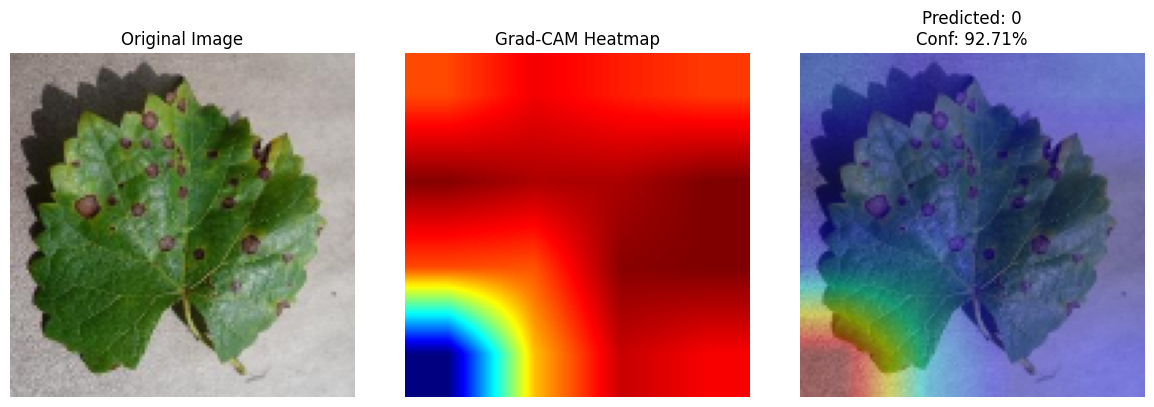

✅ IMPROVED Grad-CAM Generated Successfully


In [ ]:
# ==========================================================
# IMPROVED GRAD-CAM (STRONG VERSION)
# ==========================================================

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing import image

DATASET_PATH = "/content/drive/MyDrive/cleaned_data"
IMG_SIZE = 128
LAST_CONV_LAYER = "top_conv"

# ----------------------------------------------------------
# 1️⃣ Select ONLY Diseased Image (Not Healthy)
# ----------------------------------------------------------

all_images = []

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            # Avoid healthy folder
            if "healthy" not in root.lower():
                all_images.append(os.path.join(root, file))

random_image_path = random.choice(all_images)

print("Diseased Image Selected:")
print(random_image_path)

# ----------------------------------------------------------
# 2️⃣ Remove Softmax (Important for Strong Gradients)
# ----------------------------------------------------------

loaded_model.layers[-1].activation = None

# ----------------------------------------------------------
# 3️⃣ Load & Preprocess Image
# ----------------------------------------------------------

img = image.load_img(random_image_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# ----------------------------------------------------------
# 4️⃣ Create Grad Model
# ----------------------------------------------------------

grad_model = tf.keras.models.Model(
    [loaded_model.inputs],
    [loaded_model.get_layer(LAST_CONV_LAYER).output,
     loaded_model.output]
)

# ----------------------------------------------------------
# 5️⃣ Compute Gradients (Safe + Strong)
# ----------------------------------------------------------

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    pred_index = tf.argmax(predictions[0])
    class_channel = predictions[:, pred_index]

grads = tape.gradient(class_channel, conv_outputs)

# Fix mixed precision
conv_outputs = tf.cast(conv_outputs, tf.float32)
grads = tf.cast(grads, tf.float32)

# Channel-wise importance
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
conv_outputs = conv_outputs[0]

heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
heatmap = tf.nn.relu(heatmap)

# Normalize safely
max_val = tf.reduce_max(heatmap)
if max_val > 0:
    heatmap /= max_val

heatmap = heatmap.numpy()

# ----------------------------------------------------------
# 6️⃣ Resize & Apply Color Map
# ----------------------------------------------------------

heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# ----------------------------------------------------------
# 7️⃣ Overlay on Original Image
# ----------------------------------------------------------

original_img = cv2.imread(random_image_path)
original_img = cv2.resize(original_img, (IMG_SIZE, IMG_SIZE))

superimposed = cv2.addWeighted(original_img, 0.6, heatmap, 0.4, 0)

confidence = tf.nn.softmax(predictions)[0][pred_index] * 100
predicted_class = int(pred_index)

# ----------------------------------------------------------
# 8️⃣ Display Results
# ----------------------------------------------------------

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
plt.title(f"Predicted: {predicted_class}\nConf: {confidence:.2f}%")
plt.axis("off")

plt.tight_layout()
plt.show()

print("===================================")
print("✅ IMPROVED Grad-CAM Generated Successfully")
print("===================================")

Diseased Image Selected:
/content/drive/MyDrive/cleaned_data/Grape___Esca_(Black_Measles)/ebaef57f-4abf-4f25-8434-c94e4658a2d3___FAM_B.Msls 3825.JPG


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


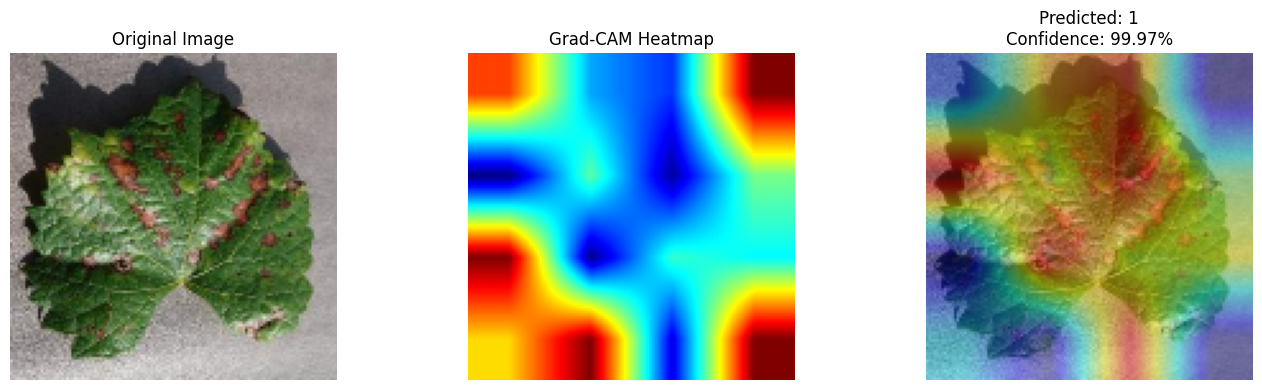

✅ FINAL CORRECT Grad-CAM Generated


In [ ]:
# ==========================================================
# CLEAN & CORRECT GRAD-CAM IMPLEMENTATION
# ==========================================================

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing import image

# ----------------------------------------------------------
# SETTINGS
# ----------------------------------------------------------

DATASET_PATH = "/content/drive/MyDrive/cleaned_data"
IMG_SIZE = 128

# Use earlier conv layer for better localization
LAST_CONV_LAYER = "block6o_project_conv"   # Better than top_conv

# ----------------------------------------------------------
# 1️⃣ Collect All Images (Exclude Healthy)
# ----------------------------------------------------------

all_images = []

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            if "healthy" not in root.lower():
                all_images.append(os.path.join(root, file))

if len(all_images) == 0:
    raise ValueError("No diseased images found. Check dataset path.")

random_image_path = random.choice(all_images)

print("Diseased Image Selected:")
print(random_image_path)

# ----------------------------------------------------------
# 2️⃣ Load & Preprocess Image
# ----------------------------------------------------------

img = image.load_img(random_image_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# ----------------------------------------------------------
# 3️⃣ Create Grad Model (NO activation modification)
# ----------------------------------------------------------

# Extract logits BEFORE softmax safely
last_layer = loaded_model.layers[-1]

if hasattr(last_layer, "activation"):
    original_activation = last_layer.activation
    last_layer.activation = tf.keras.activations.linear

grad_model = tf.keras.models.Model(
    inputs=loaded_model.input,
    outputs=[
        loaded_model.get_layer(LAST_CONV_LAYER).output,
        loaded_model.output
    ]
)

# ----------------------------------------------------------
# 4️⃣ Compute Gradients
# ----------------------------------------------------------

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    pred_index = tf.argmax(predictions[0])
    class_channel = predictions[:, pred_index]

grads = tape.gradient(class_channel, conv_outputs)

# Restore original activation
if hasattr(last_layer, "activation"):
    last_layer.activation = original_activation

# Convert to float32 (important for mixed precision)
conv_outputs = tf.cast(conv_outputs, tf.float32)
grads = tf.cast(grads, tf.float32)

# ----------------------------------------------------------
# 5️⃣ Generate Heatmap
# ----------------------------------------------------------

pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
conv_outputs = conv_outputs[0]

heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
heatmap = tf.nn.relu(heatmap)

max_val = tf.reduce_max(heatmap)
if max_val > 0:
    heatmap /= max_val

heatmap = heatmap.numpy()

# ----------------------------------------------------------
# 6️⃣ Resize & Apply Colormap
# ----------------------------------------------------------

heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
heatmap = np.uint8(255 * heatmap)
heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# ----------------------------------------------------------
# 7️⃣ Overlay on Original Image
# ----------------------------------------------------------

original_img = cv2.imread(random_image_path)
original_img = cv2.resize(original_img, (IMG_SIZE, IMG_SIZE))

overlay = cv2.addWeighted(original_img, 0.6, heatmap_color, 0.4, 0)

confidence = tf.nn.softmax(predictions)[0][pred_index] * 100
predicted_class = int(pred_index)

# ----------------------------------------------------------
# 8️⃣ Display Results
# ----------------------------------------------------------

plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap_color)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.axis("off")

plt.tight_layout()
plt.show()

print("===================================")
print("✅ FINAL CORRECT Grad-CAM Generated")
print("===================================")